In [81]:
# ==========================
# COMPLETE ML PIPELINE
# Change MODEL only and run
# ==========================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score,
    balanced_accuracy_score
)


In [82]:

# ==========================
# LOAD DATA
# ==========================
df = pd.read_csv("heart_attack_prediction_dataset.csv")

# ==========================
# DROP ID COLUMN
# ==========================
if 'Patient ID' in df.columns:
    df = df.drop('Patient ID', axis=1)

# ==========================
# SPLIT BLOOD PRESSURE
# ==========================
if 'Blood Pressure' in df.columns:
    bp = df['Blood Pressure'].str.split('/', expand=True)
    df['Systolic_BP'] = pd.to_numeric(bp[0], errors='coerce')
    df['Diastolic_BP'] = pd.to_numeric(bp[1], errors='coerce')
    df.drop('Blood Pressure', axis=1, inplace=True)


In [83]:
# ==========================
# TARGET
# ==========================
TARGET = 'Heart Attack Risk'

X = df.drop(TARGET, axis=1)
y = df[TARGET]

In [84]:
df.head()

,Age,Sex,Cholesterol,Heart Rate,Diabetes,Family History,Smoking,Obesity,Alcohol Consumption,Exercise Hours Per Week,Diet,Previous Heart Problems,Medication Use,Stress Level,Sedentary Hours Per Day,Income,BMI,Triglycerides,Physical Activity Days Per Week,Sleep Hours Per Day,Country,Continent,Hemisphere,Heart Attack Risk,Systolic_BP,Diastolic_BP
0,67,Male,208,72,0,0,1,0,0,4.168189,Average,0,0,9,6.615001,261404,31.251233,286,0,6,Argentina,South America,Southern Hemisphere,0,158,88
1,21,Male,389,98,1,1,1,1,1,1.813242,Unhealthy,1,0,1,4.963459,285768,27.194973,235,1,7,Canada,North America,Northern Hemisphere,0,165,93
2,21,Female,324,72,1,0,0,0,0,2.078353,Healthy,1,1,9,9.463426,235282,28.176571,587,4,4,France,Europe,Northern Hemisphere,0,174,99
3,84,Male,383,73,1,1,1,0,1,9.828130,Average,1,0,9,7.648981,125640,36.464704,378,3,4,Canada,North America,Northern Hemisphere,0,163,100
4,66,Male,318,93,1,1,1,1,0,5.804299,Unhealthy,1,0,6,1.514821,160555,21.809144,231,1,5,Thailand,Asia,Northern Hemisphere,0,91,88


In [85]:

# ==========================
# TARGET
# ==========================
TARGET = 'Heart Attack Risk'

X = df.drop(TARGET, axis=1)
y = df[TARGET]

# ==========================
# COLUMN TYPES
# ==========================
numeric_features = X.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()


In [86]:
df.dtypes

,0
Age,int64
Sex,object
Cholesterol,int64
Heart Rate,int64
Diabetes,int64
Family History,int64
Smoking,int64
Obesity,int64
Alcohol Consumption,int64
Exercise Hours Per Week,float64


In [87]:
# ==========================
# PREPROCESSING
# ==========================
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [88]:

# ==================================================
# SELECT ANY MODEL HERE
# ==================================================

from xgboost import XGBClassifier

MODEL = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

In [89]:
# ==================================================
# TRAIN TEST SPLIT
# ==================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


In [90]:
# ==================================================
# PIPELINE
# ==================================================

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MODEL)
])

In [91]:


# ==================================================
# TRAIN
# ==================================================

pipeline.fit(X_train, y_train)

# ==================================================
# PREDICTIONS
# ==================================================

y_pred = pipeline.predict(X_test)

try:
    y_prob = pipeline.predict_proba(X_test)[:,1]
except:
    y_prob = None

In [92]:


# ==================================================
# PERFORMANCE METRICS
# ==================================================

print("="*60)
print("MODEL PERFORMANCE")
print("="*60)

print(f"Accuracy              : {accuracy_score(y_test,y_pred):.4f}")
print(f"Precision             : {precision_score(y_test,y_pred):.4f}")
print(f"Recall                : {recall_score(y_test,y_pred):.4f}")
print(f"F1 Score              : {f1_score(y_test,y_pred):.4f}")
print(f"Balanced Accuracy     : {balanced_accuracy_score(y_test,y_pred):.4f}")
print(f"Matthews Corrcoef     : {matthews_corrcoef(y_test,y_pred):.4f}")
print(f"Cohen Kappa           : {cohen_kappa_score(y_test,y_pred):.4f}")

if y_prob is not None:
    print(f"ROC-AUC               : {roc_auc_score(y_test,y_prob):.4f}")


MODEL PERFORMANCE
Accuracy              : 0.6229
Precision             : 0.4298
Recall                : 0.1608
F1 Score              : 0.2341
Balanced Accuracy     : 0.5209
Matthews Corrcoef     : 0.0587
Cohen Kappa           : 0.0484
ROC-AUC               : 0.5233


In [93]:
import seaborn as sns


Confusion Matrix


<Axes: >

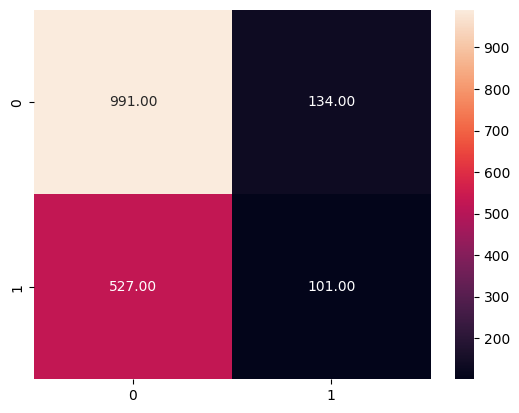

In [94]:

print("\nConfusion Matrix")
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='.2f')


In [95]:
print("\nClassification Report")
print(classification_report(y_test,y_pred))



Classification Report
              precision    recall  f1-score   support

           0       0.65      0.88      0.75      1125
           1       0.43      0.16      0.23       628

    accuracy                           0.62      1753
   macro avg       0.54      0.52      0.49      1753
weighted avg       0.57      0.62      0.57      1753



In [96]:







# ==================================================
# CROSS VALIDATION
# ==================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_accuracy = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='accuracy'
)

cv_f1 = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='f1'
)

cv_precision = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='precision'
)

cv_recall = cross_val_score(
    pipeline,
    X,
    y,
    cv=cv,
    scoring='recall'
)

print("\n" + "="*60)
print("5-FOLD CROSS VALIDATION")
print("="*60)

print(f"CV Accuracy  : {cv_accuracy.mean():.4f} ± {cv_accuracy.std():.4f}")
print(f"CV Precision : {cv_precision.mean():.4f} ± {cv_precision.std():.4f}")
print(f"CV Recall    : {cv_recall.mean():.4f} ± {cv_recall.std():.4f}")
print(f"CV F1 Score  : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")

# ==================================================
# TO USE ANOTHER ALGORITHM
# JUST REPLACE MODEL =
# ==================================================

# Random Forest
# from sklearn.ensemble import RandomForestClassifier
# MODEL = RandomForestClassifier(n_estimators=500, random_state=42)

# LightGBM
# from lightgbm import LGBMClassifier
# MODEL = LGBMClassifier(random_state=42)

# CatBoost
# from catboost import CatBoostClassifier
# MODEL = CatBoostClassifier(verbose=0, random_state=42)

# Extra Trees
# from sklearn.ensemble import ExtraTreesClassifier
# MODEL = ExtraTreesClassifier(n_estimators=500, random_state=42)

# HistGradientBoosting
# from sklearn.ensemble import HistGradientBoostingClassifier
# MODEL = HistGradientBoostingClassifier(random_state=42)

# SVM
# from sklearn.svm import SVC
# MODEL = SVC(probability=True, random_state=42)

# Logistic Regression
# from sklearn.linear_model import LogisticRegression
# MODEL = LogisticRegression(max_iter=5000)


5-FOLD CROSS VALIDATION
CV Accuracy  : 0.6036 ± 0.0049
CV Precision : 0.3504 ± 0.0245
CV Recall    : 0.1262 ± 0.0146
CV F1 Score  : 0.1854 ± 0.0190


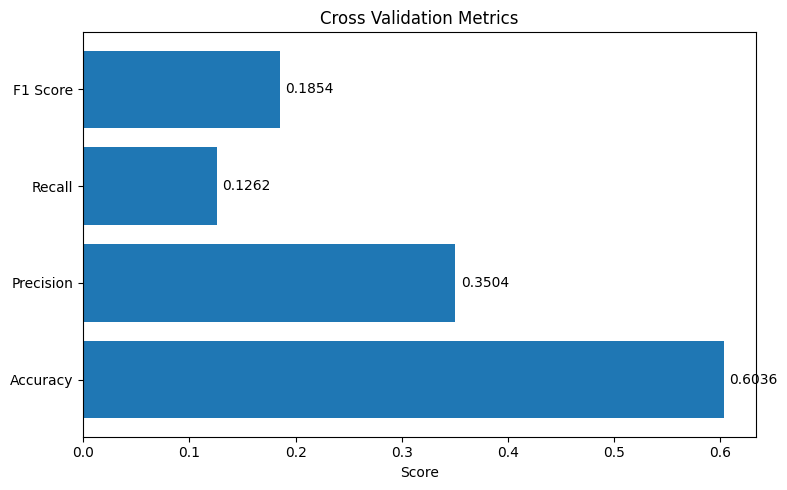

In [152]:
import matplotlib.pyplot as plt

cv_results = {
    'Accuracy': cv_accuracy.mean(),
    'Precision': cv_precision.mean(),
    'Recall': cv_recall.mean(),
    'F1 Score': cv_f1.mean()
}

plt.figure(figsize=(8,5))

bars = plt.barh(
    list(cv_results.keys()),
    list(cv_results.values())
)

for bar in bars:
    plt.text(
        bar.get_width()+0.005,
        bar.get_y()+bar.get_height()/2,
        f'{bar.get_width():.4f}',
        va='center'
    )

plt.xlabel('Score')
plt.title('Cross Validation Metrics')

plt.tight_layout()
plt.show()

## 2nd techniques

In [97]:
pip install catboost


In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    HistGradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.neural_network import MLPClassifier
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)
from sklearn.gaussian_process import GaussianProcessClassifier

# Optional (Install if not available)
# pip install xgboost lightgbm catboost

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


In [113]:

models = {

    # # Linear Models
    "Logistic Regression": LogisticRegression(max_iter=5000),

    # Tree Based Models
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),


    # Boosting Models
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),


    # Neural Network
    "MLP Neural Network": MLPClassifier(max_iter=1000, random_state=42),



    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    )

}

In [114]:
# ==========================================================
# TRAIN ALL MODELS AND CALCULATE ALL PERFORMANCE METRICS
# ==========================================================

import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    confusion_matrix
)


In [115]:

results = []

for name, model in models.items():

    print(f"\n{'='*70}")
    print(f"Training: {name}")
    print(f"{'='*70}")

    try:

        pipeline = Pipeline([
            ('preprocessor', preprocessor),
            ('model', model)
        ])

        pipeline.fit(X_train, y_train)

        y_pred = pipeline.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)
        mcc = matthews_corrcoef(y_test, y_pred)
        kappa = cohen_kappa_score(y_test, y_pred)

        try:
            y_prob = pipeline.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, y_prob)
        except:
            roc_auc = np.nan

        cm = confusion_matrix(y_test, y_pred)

        print("Confusion Matrix:")
        print(cm)

        results.append({
            "Model": name,
            "Accuracy": accuracy,
            "Precision": precision,
            "Recall": recall,
            "F1 Score": f1,
            "ROC AUC": roc_auc,
            "Balanced Accuracy": balanced_acc,
            "MCC": mcc,
            "Cohen Kappa": kappa
        })

    except Exception as e:
        print(f"Error in {name}: {e}")

# ==========================================================
# RESULTS TABLE
# ==========================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

pd.set_option('display.max_columns', None)

print("\n")
print("="*120)
print("FINAL MODEL COMPARISON")
print("="*120)

display(results_df.round(4))


Training: Logistic Regression
Confusion Matrix:
[[1125    0]
 [ 628    0]]

Training: Decision Tree
Confusion Matrix:
[[709 416]
 [389 239]]

Training: Random Forest
Confusion Matrix:
[[1111   14]
 [ 615   13]]

Training: Gradient Boosting
Confusion Matrix:
[[1103   22]
 [ 614   14]]

Training: MLP Neural Network
Confusion Matrix:
[[725 400]
 [413 215]]

Training: LightGBM
Confusion Matrix:
[[1049   76]
 [ 581   47]]


FINAL MODEL COMPARISON


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Balanced Accuracy,MCC,Cohen Kappa
0,Logistic Regression,0.6418,0.0000,0.0000,0.0000,0.5067,0.5000,0.0000,0.0000
2,Random Forest,0.6412,0.4815,0.0207,0.0397,0.5170,0.5041,0.0321,0.0105
3,Gradient Boosting,0.6372,0.3889,0.0223,0.0422,0.5106,0.5014,0.0093,0.0035
5,LightGBM,0.6252,0.3821,0.0748,0.1252,0.5144,0.5036,0.0137,0.0089
1,Decision Tree,0.5408,0.3649,0.3806,0.3726,0.5054,0.5054,0.0107,0.0107
4,MLP Neural Network,0.5362,0.3496,0.3424,0.3459,0.4756,0.4934,-0.0133,-0.0133


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [117]:
results_df.to_csv("model_comparison_results.csv", index=False)

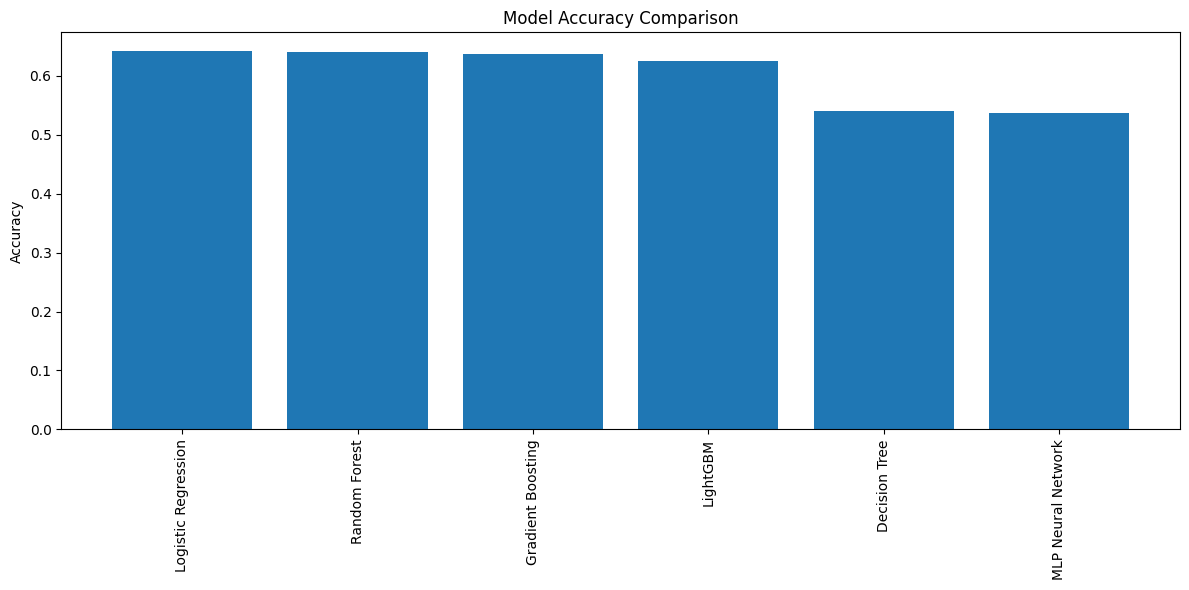

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    results_df["Model"],
    results_df["Accuracy"]
)

plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.tight_layout()
plt.show()

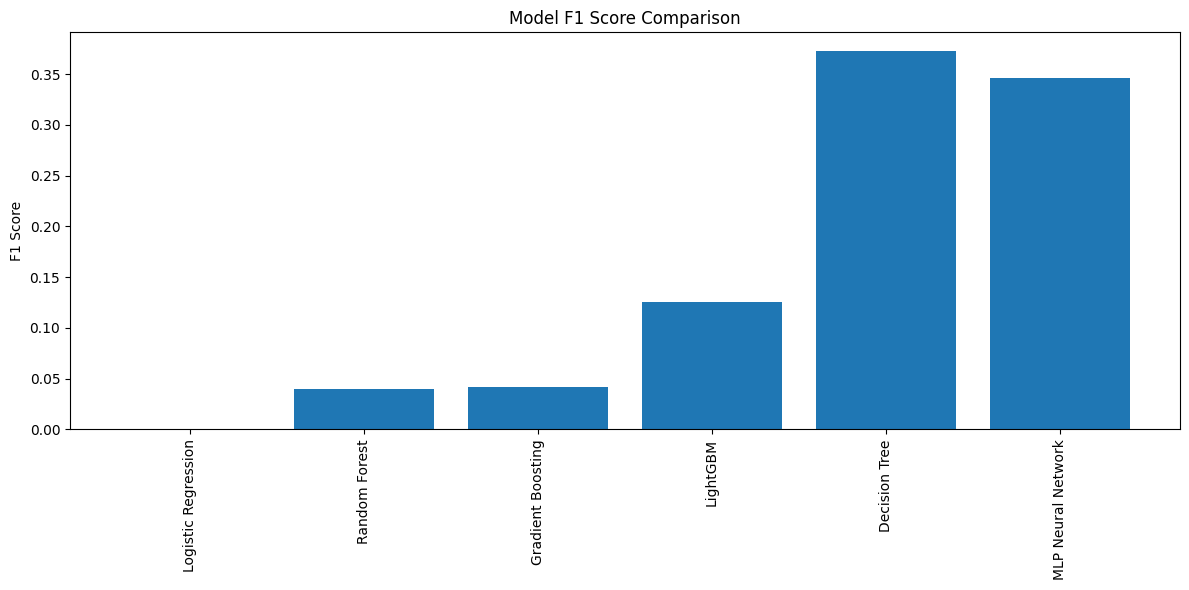

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    results_df["Model"],
    results_df["F1 Score"]
)

plt.xticks(rotation=90)
plt.ylabel("F1 Score")
plt.title("Model F1 Score Comparison")

plt.tight_layout()
plt.show()

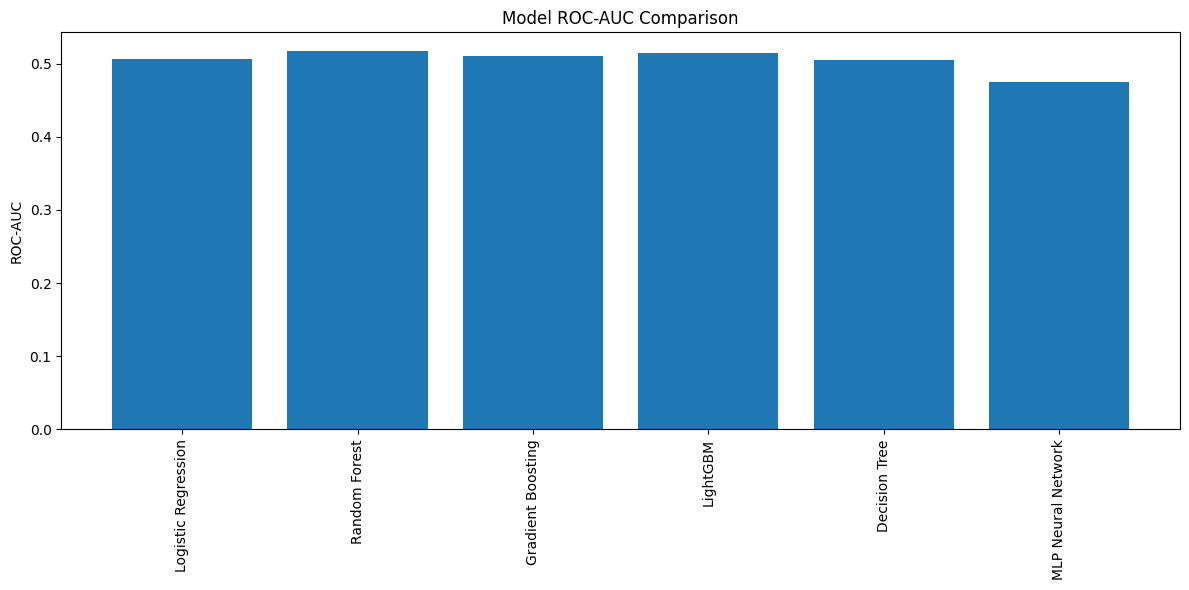

In [120]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    results_df["Model"],
    results_df["ROC AUC"]
)

plt.xticks(rotation=90)
plt.ylabel("ROC-AUC")
plt.title("Model ROC-AUC Comparison")

plt.tight_layout()
plt.show()

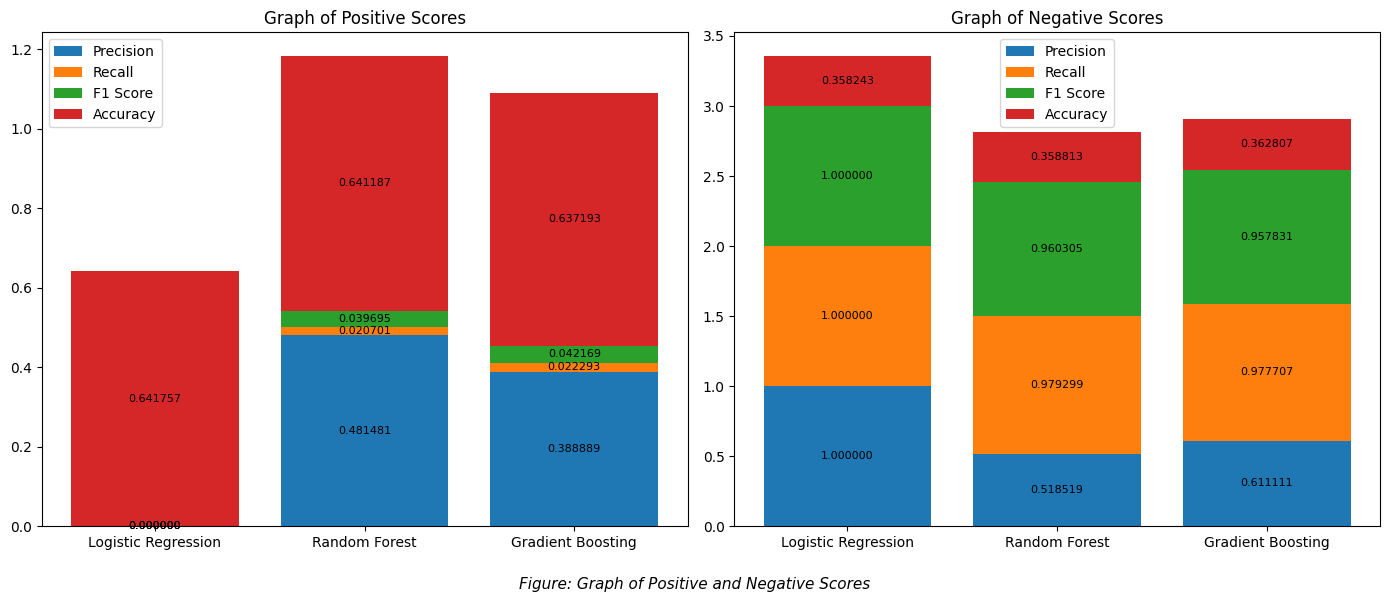

In [121]:
import matplotlib.pyplot as plt
import numpy as np

# Select top 3 models (change if needed)
top_models = results_df.sort_values('Accuracy', ascending=False).head(3)

models = top_models['Model'].values

positive_metrics = {
    'Precision': top_models['Precision'].values,
    'Recall': top_models['Recall'].values,
    'F1 Score': top_models['F1 Score'].values,
    'Accuracy': top_models['Accuracy'].values
}

negative_metrics = {
    'Precision': 1 - top_models['Precision'].values,
    'Recall': 1 - top_models['Recall'].values,
    'F1 Score': 1 - top_models['F1 Score'].values,
    'Accuracy': 1 - top_models['Accuracy'].values
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# -----------------------------
# Positive Scores
# -----------------------------
bottom = np.zeros(len(models))

for metric, values in positive_metrics.items():
    bars = axes[0].bar(models, values, bottom=bottom, label=metric)

    for i, v in enumerate(values):
        axes[0].text(
            i,
            bottom[i] + v/2,
            f'{v:.6f}',
            ha='center',
            va='center',
            fontsize=8
        )

    bottom += values

axes[0].set_title('Graph of Positive Scores')
axes[0].legend()

# -----------------------------
# Negative Scores
# -----------------------------
bottom = np.zeros(len(models))

for metric, values in negative_metrics.items():
    bars = axes[1].bar(models, values, bottom=bottom, label=metric)

    for i, v in enumerate(values):
        axes[1].text(
            i,
            bottom[i] + v/2,
            f'{v:.6f}',
            ha='center',
            va='center',
            fontsize=8
        )

    bottom += values

axes[1].set_title('Graph of Negative Scores')
axes[1].legend()

plt.figtext(
    0.5,
    0.01,
    'Figure: Graph of Positive and Negative Scores',
    ha='center',
    fontsize=11,
    style='italic'
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [122]:
models

array(['Logistic Regression', 'Random Forest', 'Gradient Boosting'],
      dtype=object)

In [123]:

models = {

    # # Linear Models
    # "Logistic Regression": LogisticRegression(max_iter=5000),

    # Tree Based Models
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),


    # Boosting Models
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    # "AdaBoost": AdaBoostClassifier(random_state=42),

    # Neural Network
    "MLP Neural Network": MLPClassifier(max_iter=1000, random_state=42),



    "LightGBM": LGBMClassifier(
        random_state=42,
        verbose=-1
    )

}

<Figure size 600x500 with 0 Axes>

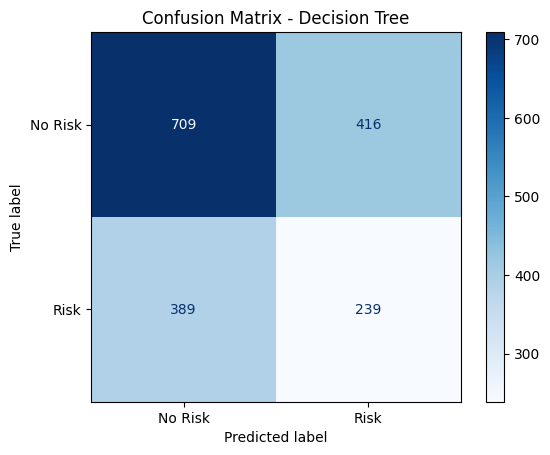

<Figure size 600x500 with 0 Axes>

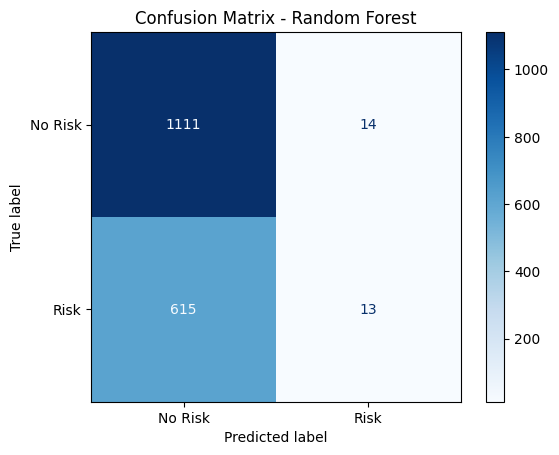

<Figure size 600x500 with 0 Axes>

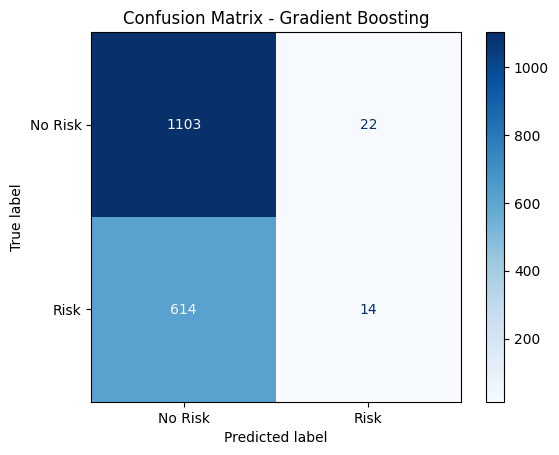

<Figure size 600x500 with 0 Axes>

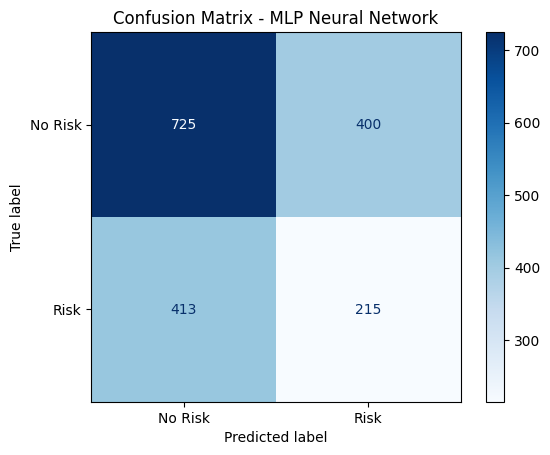

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<Figure size 600x500 with 0 Axes>

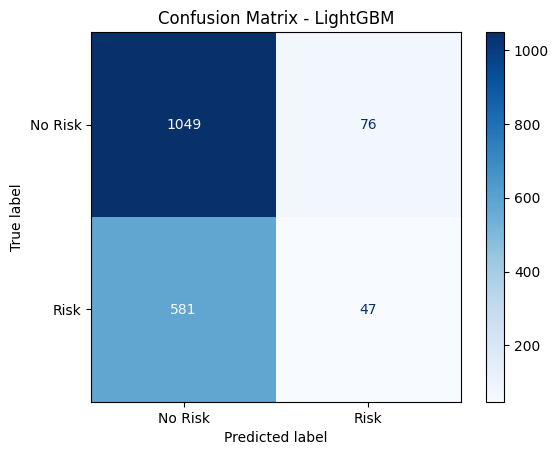

In [124]:
# ==========================================================
# CONFUSION MATRIX FOR ALL MODELS
# ==========================================================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for name, model in models.items():

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No Risk', 'Risk']
    )

    disp.plot(cmap='Blues', values_format='d')

    plt.title(f'Confusion Matrix - {name}')
    plt.grid(False)
    plt.show()

# Hyperparameter tuning

In [126]:
from sklearn.model_selection import RandomizedSearchCV

param_grids = {

    "Logistic Regression": {
        "model__C": [0.01, 0.1, 1, 10],
        "model__penalty": ["l2"],
        "model__solver": ["lbfgs", "liblinear"]
    },

    "Decision Tree": {
        "model__max_depth": [3, 5, 10, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "Random Forest": {
        "model__n_estimators": [100, 200, 300],
        "model__max_depth": [5, 10, None],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4]
    },

    "Gradient Boosting": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7]
    },

    "MLP Neural Network": {
        "model__hidden_layer_sizes": [(50,), (100,), (100,50)],
        "model__activation": ["relu", "tanh"],
        "model__alpha": [0.0001, 0.001, 0.01],
        "model__learning_rate_init": [0.001, 0.01]
    },

    "LightGBM": {
        "model__n_estimators": [100, 200, 300],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__num_leaves": [31, 50, 100],
        "model__max_depth": [-1, 5, 10]
    }
}

In [127]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd

tuning_results = []

for model_name, model in models.items():

    print(f"\n{'='*70}")
    print(f"Tuning {model_name}")
    print(f"{'='*70}")

    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grids[model_name],
        n_iter=10,              # small search
        cv=5,
        scoring='f1',
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    y_pred = best_model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    tuning_results.append({
        "Model": model_name,
        "Best CV Score": search.best_score_,
        "Test Accuracy": acc,
        "Best Parameters": search.best_params_
    })

    print("Best Score:", search.best_score_)
    print("Best Parameters:", search.best_params_)

tuning_results = pd.DataFrame(tuning_results)

display(tuning_results.sort_values(
    by="Best CV Score",
    ascending=False
))


Tuning Decision Tree
Best Score: 0.36342658836067676
Best Parameters: {'model__min_samples_split': 5, 'model__min_samples_leaf': 2, 'model__max_depth': None}

Tuning Random Forest
Best Score: 0.006308530960257188
Best Parameters: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': None}

Tuning Gradient Boosting
Best Score: 0.19429213127235187
Best Parameters: {'model__n_estimators': 300, 'model__max_depth': 7, 'model__learning_rate': 0.05}

Tuning MLP Neural Network
Best Score: 0.3655119430707455
Best Parameters: {'model__learning_rate_init': 0.001, 'model__hidden_layer_sizes': (50,), 'model__alpha': 0.01, 'model__activation': 'tanh'}

Tuning LightGBM
Best Score: 0.22089421490588745
Best Parameters: {'model__num_leaves': 50, 'model__n_estimators': 300, 'model__max_depth': 5, 'model__learning_rate': 0.1}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Model,Best CV Score,Test Accuracy,Best Parameters
3,MLP Neural Network,0.365512,0.520251,"{'model__learning_rate_init': 0.001, 'model__h..."
0,Decision Tree,0.363427,0.544780,"{'model__min_samples_split': 5, 'model__min_sa..."
4,LightGBM,0.220894,0.605248,"{'model__num_leaves': 50, 'model__n_estimators..."
2,Gradient Boosting,0.194292,0.610953,"{'model__n_estimators': 300, 'model__max_depth..."
1,Random Forest,0.006309,0.641757,"{'model__n_estimators': 200, 'model__min_sampl..."


## Getting best parameters

In [128]:
best_row = tuning_results.sort_values(
    by="Best CV Score",
    ascending=False
).iloc[0]

print("Best Model:")
print(best_row["Model"])

print("\nBest Parameters:")
print(best_row["Best Parameters"])

Best Model:
MLP Neural Network

Best Parameters:
{'model__learning_rate_init': 0.001, 'model__hidden_layer_sizes': (50,), 'model__alpha': 0.01, 'model__activation': 'tanh'}


In [129]:
# ==========================================================
# RETRAIN ALL MODELS USING BEST PARAMETERS
# ==========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

best_models = {

    "Logistic Regression": LogisticRegression(
        max_iter=5000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        min_samples_split=5,
        min_samples_leaf=2,
        max_depth=None,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        min_samples_split=10,
        min_samples_leaf=2,
        max_depth=None,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=300,
        max_depth=7,
        learning_rate=0.05,
        random_state=42
    ),

    "MLP Neural Network": MLPClassifier(
        hidden_layer_sizes=(50,),
        activation='tanh',
        alpha=0.01,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        num_leaves=50,
        n_estimators=300,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        verbose=-1
    )
}

In [130]:
best_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', MLPClassifier(
        hidden_layer_sizes=(50,),
        activation='tanh',
        alpha=0.01,
        learning_rate_init=0.001,
        max_iter=1000,
        random_state=42
    ))
])

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))

Accuracy : 0.5202509982886481
Precision: 0.3296
Recall   : 0.32802547770700635
F1 Score : 0.32881085395051873


In [132]:
['Model','Accuracy','Precision','Recall','F1 Score','ROC AUC']


['Model', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC']

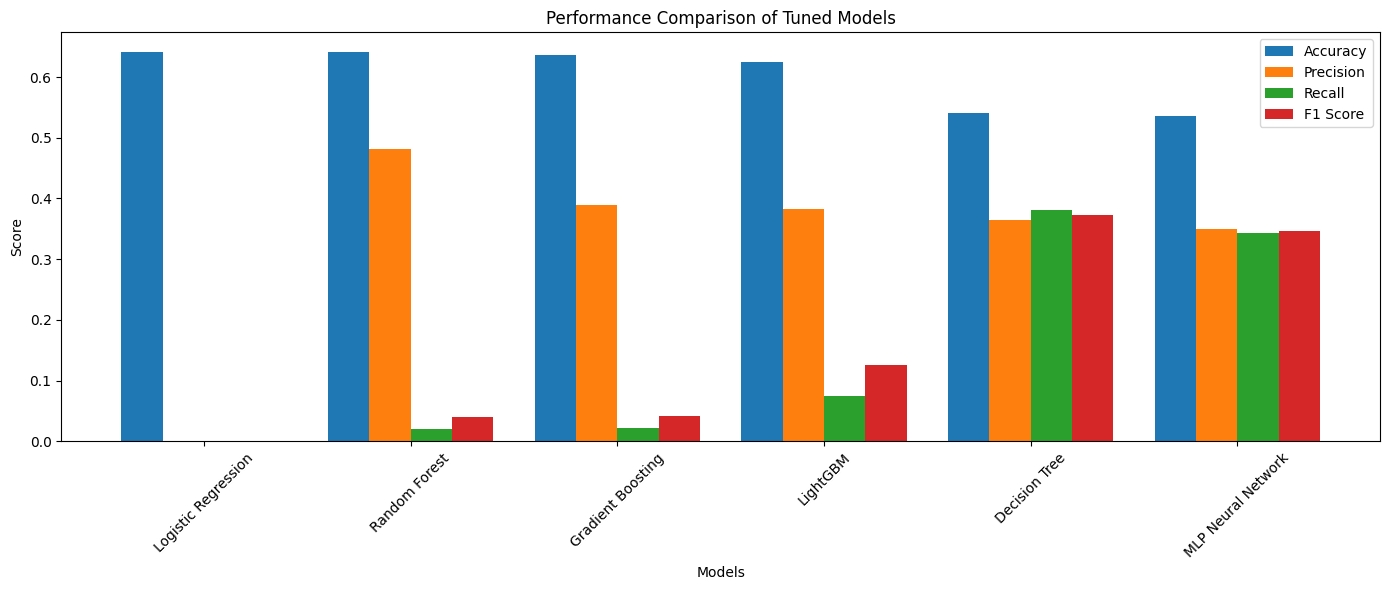

In [133]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

x = np.arange(len(results_df))
width = 0.2

plt.figure(figsize=(14,6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i*width,
        results_df[metric],
        width,
        label=metric
    )

plt.xticks(
    x + width*1.5,
    results_df['Model'],
    rotation=45
)

plt.ylabel('Score')
plt.xlabel('Models')
plt.title('Performance Comparison of Tuned Models')
plt.legend()

plt.tight_layout()
plt.show()

In [134]:
# Class Imabalance

In [135]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=10,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', rf)
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [136]:
LogisticRegression(
    max_iter=5000,
    class_weight='balanced'
)

LogisticRegression(class_weight='balanced', max_iter=5000)

In [137]:
DecisionTreeClassifier(
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)

DecisionTreeClassifier(class_weight='balanced', min_samples_leaf=2,
                       min_samples_split=5, random_state=42)

In [138]:
## 2- Smote

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=200,
        min_samples_split=10,
        min_samples_leaf=2,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

In [150]:
print(y_train.value_counts())

X_train_processed = preprocessor.fit_transform(X_train)

X_smote, y_smote = SMOTE(random_state=42).fit_resample(
    X_train_processed,
    y_train
)

print(pd.Series(y_smote).value_counts())



Heart Attack Risk
0    4499
1    2511
Name: count, dtype: int64
Heart Attack Risk
0    4499
1    4499
Name: count, dtype: int64


<Axes: xlabel='Heart Attack Risk', ylabel='count'>

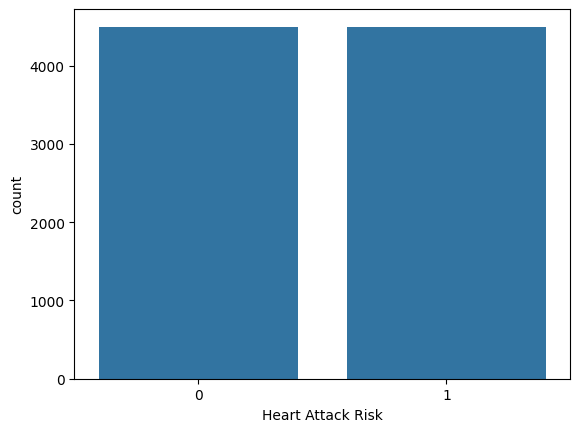

In [149]:
sns.barplot(pd.Series(y_smote).value_counts())

In [140]:
# Random Undersampling

from imblearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('undersample', RandomUnderSampler(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=200,
        min_samples_split=10,
        min_samples_leaf=2,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)


Heart Attack Risk
0    2511
1    2511
Name: count, dtype: int64


<Axes: xlabel='Heart Attack Risk', ylabel='count'>

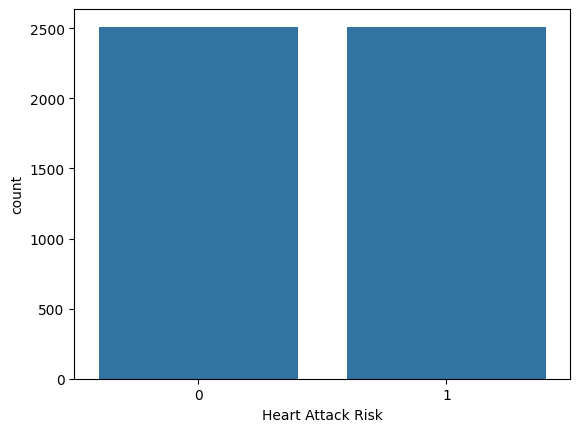

In [147]:
from imblearn.under_sampling import RandomUnderSampler

X_train_processed = preprocessor.fit_transform(X_train)

X_under, y_under = RandomUnderSampler(
    random_state=42
).fit_resample(
    X_train_processed,
    y_train
)

print(pd.Series(y_under).value_counts())

sns.barplot(pd.Series(y_under).value_counts())